# In-Class Assignment 11

## Stellar Atmospheres

### Learning Objectives

- explore conditions at / near the stellar photosphere
- compare surface conditions to analytic estimates
- qualitatively describe properties of the stellar atmosphere
- (optional) use `tulips` to visualize the stellar atmosphere

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## a. Stellar Atmosphere in a Solar-like star

### **Individually/ with the person next to you**:

Download, or reuse from a previous class:

* New $1 M_\odot$ MS model: [1m_ms_profile.data'](data/1m_ms_profile.data');

Using the $1M_\odot$ model MESA profile data (`1m_ms_profile.data'`):

1. Plot the log gas pressure ($P_{\rm{gas}}$) and log radiation pressure ($P_{\rm{rad}}$) as a function of the log `optical_depth` ($\tau$) (x-axis).


We saw in HKT 4.3 that we can use the equation of HSE to calculate photospheric pressure as a function of $g$ and $\tau$. 

Eq. 4.48 

$$
P(\tau_{\rm{P}}) = \frac{2}{3}\frac{g_{\rm{S}}}{\kappa_{\rm{P}}} \left ( 1 + \frac{\kappa_{\rm{P}}L}{4 \pi c G M} \right ) \equiv \frac{2}{3}\frac{g_{\rm{S}}}{\kappa_{\rm{P}}} \left ( 1 + \frac{L}{L_{\rm{edd}}} \right )
$$

where $g_{\rm{s}}=G M/R^2$ and $L_{\rm{edd}}= 4 \pi c G M/\kappa_{\rm{P}}$ is the _Eddington critical luminosity_

and Eq. 4.54

$$
\boxed{P(\tau_{\rm{P}}) \approx \frac{2}{3}\frac{g_{\rm{S}}}{\kappa_{\rm{P}}}}
$$


2. Use this equation to compute the analytical estimate for pressure at the photosphere for this model (ignoring the eddington luminosity term).

3. Add this estimated value to the same plot using a plt.axhline for the value obtained.

> Hint: dont forget to take the log of the value and make sure you are in CGS.

4. Also plot the ratio of the total luminosity to that of the Eddington luminosity as a function of optical depth again.

In [2]:
# load the data here
one_m_ms_profile = pd.read_csv('data/1m_ms_profile.data',sep=r'\s+',header=4)
#list(one_m_ms_profile)

In [3]:
msun_cgs  = 2e33
lsun = 4e33
G_cgs = 6.67e-8
one_m_ms_profile_Pgas = one_m_ms_profile['pgas'] # radiation pressure
one_m_ms_profile_Prad = one_m_ms_profile['prad'] # gas pressure
one_m_ms_profile_kappa = one_m_ms_profile['opacity'] # kappa
one_m_ms_profile_total_mass = max(one_m_ms_profile['mass'])*msun_cgs # M 
one_m_ms_profile_total_radius_cm = max(one_m_ms_profile['radius_cm']) # R
one_m_ms_profile_tau = one_m_ms_profile['tau']  # optical depth
one_m_ms_profile_L = 10**(one_m_ms_profile['logL']) # total L
one_m_ms_profile_Ledd = 10**(one_m_ms_profile['log_Ledd']) # L edd

In [4]:
gs = (G_cgs*one_m_ms_profile_total_mass/(one_m_ms_profile_total_radius_cm)**2)
P = 2./3. * (gs/one_m_ms_profile_kappa[0]) # the photosphere value of the opacity is at index `[0]`

Text(0, 0.5, '$\\rm{log}~P \\ (\\rm{erg\\ \\rm{s}^{-1}})$')

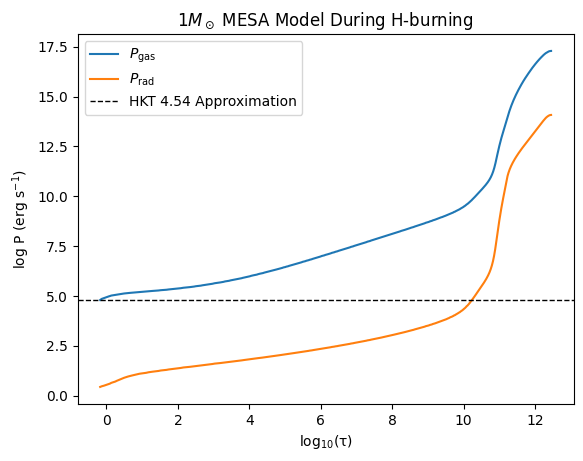

In [5]:
## 1-3 result here
plt.title('1$M_\odot$ MESA Model During H-burning')

plt.plot(np.log10(one_m_ms_profile_tau),
         np.log10(one_m_ms_profile_Pgas),label=r'$P_{\rm{gas}}$')

plt.plot(np.log10(one_m_ms_profile_tau),
         np.log10(one_m_ms_profile_Prad),label=r'$P_{\rm{rad}}$')


plt.axhline(np.log10(P),color='k',lw=1,ls='--',label=r'HKT 4.54 Approximation')

plt.legend()
plt.xlabel(r'$\rm{log}_{10}(\tau)$')
plt.ylabel(r'$\rm{log}~P \ (\rm{erg\ \rm{s}^{-1}})$')

Text(0, 0.5, '$\\rm{log}~ (L/L_{\\rm{Edd}})$')

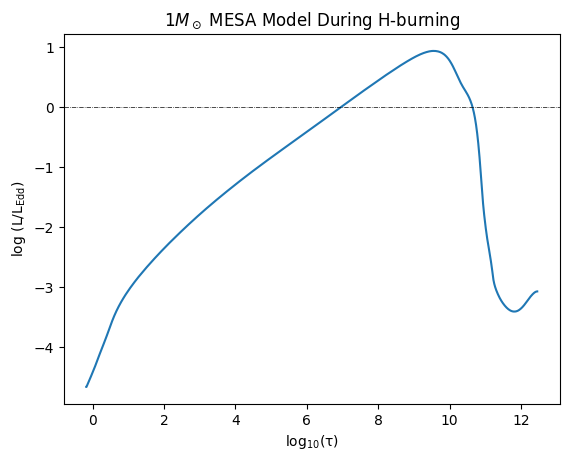

In [6]:
## 4 result here
plt.title('1$M_\odot$ MESA Model During H-burning')

plt.plot(np.log10(one_m_ms_profile_tau),
         np.log10(one_m_ms_profile_L/one_m_ms_profile_Ledd))

plt.axhline(0,lw=0.5,ls='-.',color='k')

plt.xlabel(r'$\rm{log}_{10}(\tau)$')
plt.ylabel(r'$\rm{log}~ (L/L_{\rm{Edd}})$')

### **With your larger group, try to answer the following**:

5. Where is the surface (or in this case the atmosphere) on this plot?

> To the left of the plot at $\tau=2/3$.

6. Does the estimated pressure for this model match the value at the photosphere?

> Yes, our estimate is valid. 

7. In the second plot, does the luminosity ever exceed the eddington luminosity in the model near the atmosphere?

> No, it is a small fraction near the surface. 

8. What might these results suggest about the validity of the analytical estimate we compared against?

> Valid, in due part to not radiation pressure dominated. 


## b. Stellar Atmosphere in a Massive star

### **Individually/ with the person next to you**:

Download, or reuse from a previous class:

* $20 M_\odot$ MS model: [20m_ms_profile.data](data/20m_ms_profile.data);

Using the $20M_\odot$ model MESA profile data (`20m_ms_profile.data`):

1. Plot the log gas pressure ($P_{\rm{gas}}$) and log radiation pressure ($P_{\rm{rad}}$) as a function of the `optical_depth` ($\tau$) (x-axis).

2. Use this equation to compute the analytical estimate for pressure at the photosphere for this model (ignoring the eddington luminosity term).

3. Add this estimated value to the same plot using a plt.axhline for the value obtained.

> Hint: dont forget to take the log of the value and make sure you are in CGS.

4. Also plot the ratio of the total luminosity to that of the Eddington luminosity as a function of optical depth again.

This plot shows the ranges over which MESA uses different [atmosphere boundary conditions](https://iopscience.iop.org/article/10.1088/0067-0049/192/1/3#apjs374559f6).

In [7]:
# load data with pandas
one_m_ms_profile = pd.read_csv('data/20m_ms_profile.data',sep=r'\s+',header=4)
#list(one_m_ms_profile)

In [8]:
# load variables here
one_m_ms_profile_Pgas = one_m_ms_profile['pgas'] # radiation pressure
one_m_ms_profile_Prad = one_m_ms_profile['prad'] # gas pressure
one_m_ms_profile_kappa = one_m_ms_profile['opacity'] # kappa
one_m_ms_profile_total_mass = max(one_m_ms_profile['mass'])*msun_cgs # M 
one_m_ms_profile_total_radius_cm = max(one_m_ms_profile['radius_cm']) # R
one_m_ms_profile_tau = one_m_ms_profile['tau']  # optical depth
one_m_ms_profile_L = 10**(one_m_ms_profile['logL']) # total L
one_m_ms_profile_Ledd = 10**(one_m_ms_profile['log_Ledd']) # L edd

In [9]:
# compute g at the surface
gs = (G_cgs*one_m_ms_profile_total_mass/(one_m_ms_profile_total_radius_cm)**2)

# compute analytical P value
P = 2./3. * (gs/one_m_ms_profile_kappa[0]) # the photosphere value of the opacity is at index `[0]`

Text(0, 0.5, '$\\rm{log}~P \\ (\\rm{dyne\\ \\rm{cm}^{-2}})$')

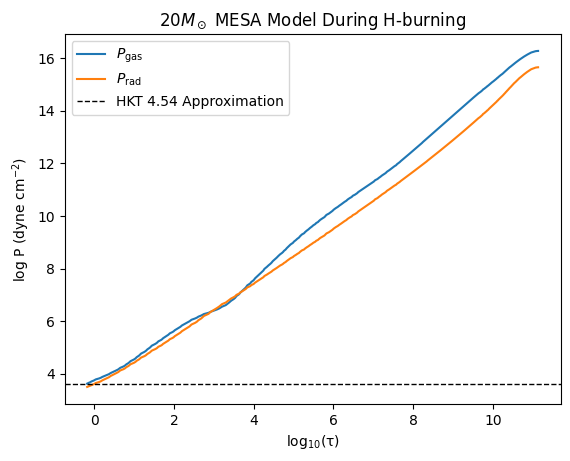

In [10]:
## 1-3 result here
plt.title('20$M_\odot$ MESA Model During H-burning')

plt.plot(np.log10(one_m_ms_profile_tau),
         np.log10(one_m_ms_profile_Pgas),label=r'$P_{\rm{gas}}$')

plt.plot(np.log10(one_m_ms_profile_tau),
         np.log10(one_m_ms_profile_Prad),label=r'$P_{\rm{rad}}$')

plt.axhline(np.log10(P),color='k',lw=1,ls='--',label=r'HKT 4.54 Approximation')

plt.legend()
plt.xlabel(r'$\rm{log}_{10}(\tau)$')
plt.ylabel(r'$\rm{log}~P \ (\rm{dyne\ \rm{cm}^{-2}})$')

Text(0, 0.5, '$\\rm{log}~ (L/L_{\\rm{Edd}})$')

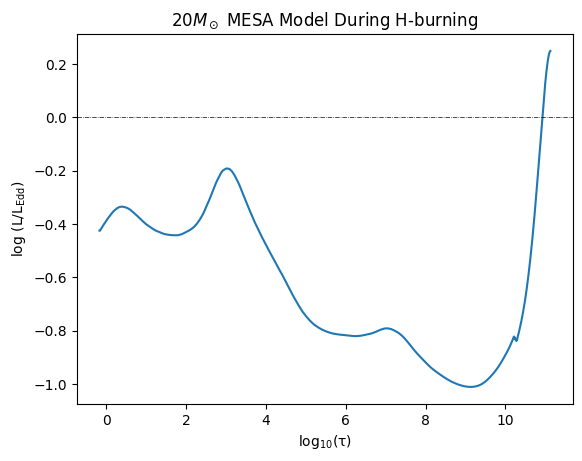

In [11]:
## 1-2 result here
plt.title('20$M_\odot$ MESA Model During H-burning')

plt.plot(np.log10(one_m_ms_profile_tau),
         np.log10(one_m_ms_profile_L/one_m_ms_profile_Ledd),label=r'$L/L_{\rm{Edd}}$')

plt.axhline(0,lw=0.5,ls='-.',color='k')

plt.xlabel(r'$\rm{log}_{10}(\tau)$')
plt.ylabel(r'$\rm{log}~ (L/L_{\rm{Edd}})$')

### **With your larger group, try to answer the following**:

5. How do the different pressure contributions differ in this model compared to the previous one?

> Massive star is approaching radiation dominated in the atmosphere.

6. Does the estimated pressure for this model match the value at the photosphere?

> Yes, estimate is still valid.

7. In the second plot, does the luminosity ever exceed the eddington luminosity in the model near the atmosphere?

> No, but it becomes closer to exceeding. 

8. What might these results suggest about the validity of the analytical estimate we compared against?

> Implying the need for a different treatment at the surface accounting for large radiation pressure on the material in the surface. Important for massive stars especially those as wolf-rayet stars and others. 